## Logistic Regression & Classification Metrics
In this notebook I learn about Logistic Regression which is very popular classification algorithm in supervised learning.
As opposed in Linear Regression which output is countinous value Logistic Regression outputs probabillites and classes,here I build a classification model using Scikit-learn,test it in various performance metrics and learn why accuracy might not be enogh to measure model performance.

## Import Libraries

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay,RocCurveDisplay,roc_auc_score
from sklearn.model_selection import train_test_split

## Load the Dataset

In [5]:
df=pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


## Dataset
Dataset for binary classification (stroke : 0 or 1) based on demographic, lifestyle, and health factors and Requires handling missing values in bmi.

In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
df["bmi"]=df["bmi"].fillna((df["bmi"]).mean())

In [8]:
df=df.drop("id",axis=1)

because id column does not useful for the model.

In [10]:
df=pd.get_dummies(df,drop_first=True)
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.600000,1,True,False,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.893237,1,False,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.500000,1,True,False,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.400000,1,False,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.000000,1,False,False,True,False,False,True,False,False,False,True,False


## Features and Target columns
The target variable is stroke ,so the remaining columns will be used as input features

In [11]:
x=df.drop("stroke",axis=1)
y=df["stroke"]

## Split the dataset
The dataset is split between the training and testing datasets,the training dataset is employed for training the model and the testing dataset is employed for assessing the model's performance on new data

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x.shape)
print(y.shape)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(5110, 16)
(5110,)
(4088, 16)
(4088,)
(1022, 16)
(1022,)


## Build the logistic Regression Model

In [ ]:
model=LogisticRegression(max_iter=1000)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Training the Model
The model is trained to learn the mapping between inputs and outputs variables.

In [ ]:
model.fit(x_train,y_train)

## Predictions

In [20]:
predictions=model.predict(x_test)
probabilities=model.predict_proba(x_test)[:,1]

Makes final class predictions and extract the probability of stroke (class 1) for evaluation.

## Accuracy
it is the percentage of correctly predicted patients but stroke data is unbalanced therefor accuracy can be misleading when assessing the model

In [21]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)
print("the value of accuracy is:",accuracy)

the value of accuracy is: 0.9393346379647749


## Confusion Matrix

In [ ]:
confusion_matrix=confusion_matrix(y_test,predictions)
print("the value of Confusion Matrix is:",confusion_matrix)


the value of Confusion Matrix is: [[960   0]
 [ 62   0]]


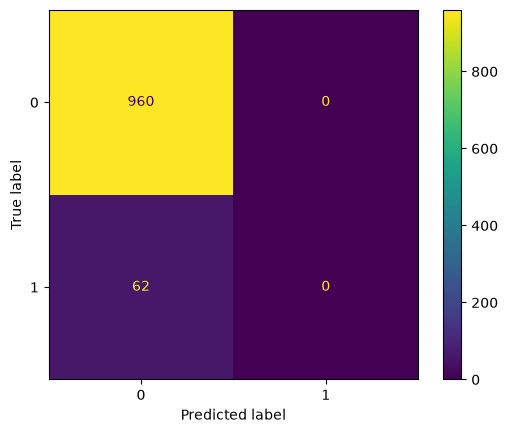

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test,predictions)
plt.show()

In [26]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

From the dataset distribution shown above:
- Non-Stroke (0): 4,861 observations
- Stroke (1): 249 observations
The dataset is an example of a **strongly imbalanced dataset**, where strokes account for a small percentage of the total dataset.
## What could have caused the model to fail to identify any strokes?
Despite the high accuracy that the model appears to have, a closer look at the Confusion Matrix shows that it totally fails to predict any strokes (0 true positives). The model just cheats by predicting the most frequent class (0) for everything to reduce errors, making accuracy a deceiving measure in this case.

## Classification Report


In [28]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

- Percision: represents the number of predicted stroke patients that are actually stroke.
- Recall: represents the number of actual stroke patients that were successfully predicted.
- F1-score: is the balanced combination of precision and recall.
- Support: represents the actual number of true occurrences for each class in the test dataset (y_test).

## ROC Curve (Receiver Operating Characteristic)


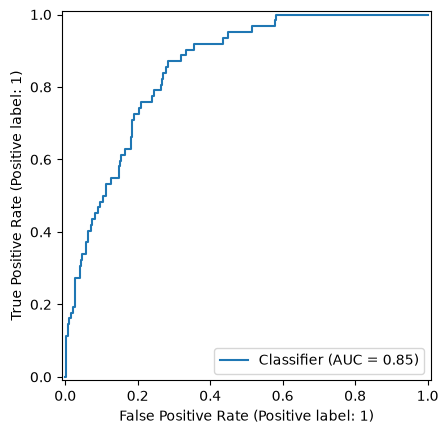

In [33]:
RocCurveDisplay.from_predictions(y_test,probabilities)
plt.show()


## AUC Score

In [35]:
auc_score=roc_auc_score(y_test,probabilities)
print("auc score value is:",auc_score)

auc score value is: 0.8516969086021505


## Hands-On-Lab (Tasks)

## Step 1: Train a LogisticRegression model on a provided classification dataset (e.g. churn).

done Training a Logistic Regression model to classify if a patient is having a stroke or not.

## Step 2: Generate predictions and produce the confusion matrix.


In [37]:
predictions=model.predict(x_test)
probabilities=model.predict_proba(x_test)[:,1]


In [38]:
confusion_matrix=confusion_matrix(y_test,predictions)
print("the value of Confusion Matrix is:",confusion_matrix)

the value of Confusion Matrix is: [[960   0]
 [ 62   0]]


## Step 3: Compute precision, recall, and F1 with classification_report, and interpret each.

In [39]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ayman\miniconda3\envs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

- Percision: represents the number of predicted stroke patients that are actually stroke.
- Recall: represents the number of actual stroke patients that were successfully predicted.
- F1-score: is the balanced combination of precision and recall.
- Support: represents the actual number of true occurrences for each class in the test dataset (y_test).

## Step 4: Decide whether precision or recall matters more for this specific problem and justify it

Recall is the most important metric in predicting stroke orrurance,Failure to detect a person who has a stroke (false negative) may result in delayed treatment.
Hence,maximizing the Recall metric is more important than Percision for medical application.

## Step 5: Compute the AUC-ROC and document what it says about the model.

In [41]:
auc_score=roc_auc_score(y_test,probabilities)
print("auc score value is:",auc_score)

auc score value is: 0.8516969086021505


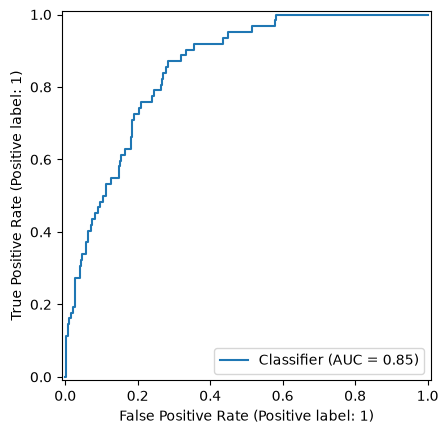

In [40]:
RocCurveDisplay.from_predictions(y_test,probabilities)
plt.show()

- What does it show?: The ROC curve measures the ability of the model to separate non-stroke (0) from stroke (1) patients at all possible decision thresholds.
- AUC Score (0.85): An AUC score of 0.85 signifies good classification capability, thereby indicating that the model has a very strong inherent capability to separate the two classes.
- Bottom Line: Even though the default decision threshold (0.5) has not worked for the confusion matrix, the excellent AUC score is a clear indication that the model is working fine—it only needs optimization of the decision threshold.

The ROC_AUC score represents how good the classifier can distinguish stroke patients from non-stroke patients,a higher score means better classification performance.